# Data Preprocessing

## Imports

In [10]:
import pandas as pd
import os
from scipy import sparse

cleaned_data_path = "../data/cleaned_data/"
model_data_path = "../data/modeling_data/"

def save_model_data(df, file_name):
    os.makedirs(model_data_path, exist_ok=True)
    df.to_csv(model_data_path + file_name, index=False)

## Online Retail Data

In [11]:
online_retail_data = pd.read_csv(cleaned_data_path + "online_retail_data_clean.csv")
online_retail_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Feature Engineering:
- Totalprice = Quantity * UnitPrice
- InvoiceDate = Date, Time, Month, DayofWeek

In [12]:
online_retail_data['TotalPrice'] = (
    online_retail_data['Quantity'] * online_retail_data['UnitPrice']
)
online_retail_data['InvoiceDate'] = pd.to_datetime(
    online_retail_data['InvoiceDate'], errors='coerce'
)
online_retail_data['InvoiceHour'] = online_retail_data['InvoiceDate'].dt.hour
online_retail_data['InvoiceDay'] = online_retail_data['InvoiceDate'].dt.day
online_retail_data['InvoiceMonth'] = online_retail_data['InvoiceDate'].dt.month
online_retail_data['InvoiceDow'] = online_retail_data['InvoiceDate'].dt.dayofweek
online_retail_data['IsCancelled'] = (
    online_retail_data['InvoiceNo'].astype(str).str.startswith('C')
)

online_retail_data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceHour,InvoiceDay,InvoiceMonth,InvoiceDow,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,8,1,12,2,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,1,12,2,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,1,12,2,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,1,12,2,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,1,12,2,False


### Split the Timeline
- Divided customer history into two periods:
  - **Past period** (first 70% of time)
  - **Future period** (last 30% of time)
- These periods do NOT overlap

### Calculate Features from Past Only
- Used only the **past period** data
- Calculated: Recency, Frequency, UniqueItems, AvgBasketQty, AvgUnitPrice, CancelRatio
- Features represent "how customer behaved historically"

### Define New Target Variable from Future Only
- Used only the **future period** data
- Calculated spending and purchase frequency in the future
- Created new label based on future behavior

### Combined Past Features with Future Target
- Merged the two together by CustomerID
- Now predicting future behavior from past behavior


## New Target Variable

**Definition:**
- `HighValueCustomer = 1` if BOTH conditions met in **future period**:
  - Customer spent ≥ 50th percentile (top half of spenders)
  - Customer purchased frequently (< 4 days between purchases on average)
- `HighValueCustomer = 0` otherwise



In [13]:
import pandas as pd
import numpy as np


max_date = online_retail_data["InvoiceDate"].max()
min_date = online_retail_data["InvoiceDate"].min()

total_days = (max_date - min_date).days
feature_cutoff = min_date + pd.Timedelta(days=int(total_days * 0.7))

print(f"Feature period: {min_date.date()} to {feature_cutoff.date()}")
print(f"Target period: {feature_cutoff.date()} to {max_date.date()}")

feature_data = online_retail_data[online_retail_data["InvoiceDate"] <= feature_cutoff]
target_data = online_retail_data[online_retail_data["InvoiceDate"] > feature_cutoff]

print(f"\nFeature data: {len(feature_data)} rows")
print(f"Target data: {len(target_data)} rows")

g_features = feature_data.groupby("CustomerID")

customer_features = pd.DataFrame({
    "Recency": (feature_cutoff - g_features["InvoiceDate"].max()).dt.days,
    "Frequency": g_features["InvoiceNo"].nunique(),
    "UniqueItems": g_features["Description"].nunique(),
    "AvgBasketQty": g_features["Quantity"].sum() / g_features["InvoiceNo"].nunique(),
    "AvgUnitPrice": g_features["UnitPrice"].mean(),
    "CancelRatio": g_features["InvoiceNo"].apply(
        lambda x: x.astype(str).str.startswith("C").mean()
    ),
}).reset_index()

print(f"\nCustomers with features: {len(customer_features)}")


g_target = target_data.groupby("CustomerID")

lifetime_spend_future = g_target["TotalPrice"].sum()
spend_threshold = lifetime_spend_future.quantile(0.50)
big_spender = lifetime_spend_future >= spend_threshold

avg_interpurchase_future = g_target["InvoiceDate"].apply(
    lambda x: x.sort_values().diff().dt.days.mean()
)
engaged = avg_interpurchase_future < 4

label = (big_spender & engaged).astype(int)
label_df = pd.DataFrame({"CustomerID": label.index, "HighValueCustomer": label.values})

print(f"Customers with labels: {len(label_df)}")


customer_features = customer_features.merge(label_df, on="CustomerID", how="inner")

print(f"\nFinal dataset: {len(customer_features)} customers")
print(f"\nLabel distribution:")
print(customer_features["HighValueCustomer"].value_counts(normalize=True))


print(f"   Features calculated from: {min_date.date()} to {feature_cutoff.date()}")
print(f"   Target calculated from: {feature_cutoff.date()} to {max_date.date()}")
print(f"   These periods do NOT overlap!")

X = customer_features.drop(["CustomerID", "HighValueCustomer"], axis=1)
y = customer_features["HighValueCustomer"]

Feature period: 2010-12-01 to 2011-08-19
Target period: 2011-08-19 to 2011-12-09

Feature data: 221384 rows
Target data: 185445 rows

Customers with features: 3296
Customers with labels: 3088

Final dataset: 2012 customers

Label distribution:
HighValueCustomer
1    0.546223
0    0.453777
Name: proportion, dtype: float64
   Features calculated from: 2010-12-01 to 2011-08-19
   Target calculated from: 2011-08-19 to 2011-12-09
   These periods do NOT overlap!


In [14]:
customer_features.head()

,CustomerID,Recency,Frequency,UniqueItems,AvgBasketQty,AvgUnitPrice,CancelRatio,HighValueCustomer
0,12347.0,16,5,82,318.0,2.797661,0.000000,1
1,12348.0,135,3,22,708.0,4.864643,0.000000,0
2,12352.0,149,8,26,23.5,39.584792,0.208333,1
3,12356.0,132,2,53,793.0,2.897719,0.000000,0
4,12358.0,37,1,12,100.0,7.719167,0.000000,1


In [15]:
save_model_data(customer_features, "customer_features_model.csv")

## Wine Dataset

- We combine the Red Wine and White Wine Quality datasets from UCI into a single unified dataset.
- A new binary target variable `is_red` is created:
  - `1` = red wine
  - `0` = white wine
- All original chemical features (acidity, chlorides, sulfur dioxide, alcohol, etc.) are kept as input features.
- The target variable `is_red` is used for a binary classification task:
  - Predict whether a wine sample is red or white based solely on its chemical properties.
- No data splitting or preprocessing occurs during merging; the dataset is simply concatenated and exported.
- The merged dataset becomes a clean, ready-to-use input for evaluating and comparing multiple classifiers.
- This classification task is leak-free and typically achieves high accuracy, but we will drop ```quality``` here to make it a bit more difficult for the classifier to differentiate between red and white


In [16]:
red = pd.read_csv(cleaned_data_path + "wine_red_data_clean.csv")
white = pd.read_csv(cleaned_data_path + "wine_white_data_clean.csv")

# Add binary label: 1 = red, 0 = white
red["is_red"] = 1
white["is_red"] = 0

# Merge into one unified dataset
wine_combined = pd.concat([red, white], ignore_index=True)

In [17]:
save_model_data(wine_combined, "wine_combined_data_model.csv")

## Cup98

- The CUP98 dataset is already structured as a supervised learning problem with a built-in binary target variable, `TARGET_B`, which indicates whether a customer made a donation.
- Because the target is clearly defined and widely used in prior work—including the paper we reference—we do not need to engineer a new label.
- The research study explicitly uses CUP98 “as is,” evaluating classifiers directly on `TARGET_B`, so we follow the same methodology for consistency.
- But we will limit the feature dimensions here for the sake of computational time and complexity
- CUP98 contains a rich set of demographic and historical donation features, which can be used directly without additional feature engineering.
- Apart from removing ID-like or leakage columns, the dataset requires no modification before modeling.
- Using the dataset as provided ensures a fair, standard comparison across models and aligns with established practices in the literature.


### Addressing Possible Leakage

- The CUP98 dataset includes several variables that were collected **after** the mailing campaign or were never intended for prediction; these are considered **leakage features** because they contain information that would not be available at prediction time.
- Even though these leakage variables appear in the dataset, **using them in a predictive model is not valid**, because it provides the model with unfair knowledge about the outcome.
- Examples include:
  - Unique identifiers (e.g., CONTROLN), which carry no predictive value and can cause the model to memorize rows.
  - Mailing dates or campaign metadata (e.g., MAILDATE) that were assigned after segmentation and may correlate with donation outcomes.
  - Administrative flags (e.g., HPHONE_D) that may reflect internal processing decisions that occurred after the donation behavior.
- Using leakage features leads to **inflated accuracy** during evaluation but produces a model that fails in real deployment because it relies on information it would never have at prediction time.
- For this reason, even though the dataset includes these variables, we **intentionally remove them** to ensure a fair, realistic supervised learning setup that matches the methodology used in prior research.
- https://github.com/rebordao/kdd98cup, we are using this guide to drop the relevant feature leakage.

In [18]:
cup98 = pd.read_csv(cleaned_data_path + "cup98_data_clean.csv")

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt



categorical_cols = cup98.select_dtypes(include=['object']).columns 


df_encoded = pd.get_dummies(cup98, columns=categorical_cols, drop_first=True) 


numeric_df = df_encoded.select_dtypes(include=['number']) 
numeric_df = numeric_df.fillna(numeric_df.mean())  





In [20]:
correlation_matrix = numeric_df.corr()

target_correlation = correlation_matrix['TARGET_B'].sort_values(ascending=False)

# Step 6: Display the top features most correlated with TARGET_B (excluding TARGET_B itself)
top_features_with_target = target_correlation.drop('TARGET_B').head(10)  # Top 10 features
print("Top 10 features most correlated with TARGET_B:")
print(top_features_with_target)


Top 10 features most correlated with TARGET_B:
TARGET_D    0.774232
RFA_2F      0.072311
CARDGIFT    0.054027
NGIFTALL    0.050896
LASTDATE    0.041158
NUMPROM     0.033161
CARDPROM    0.032467
HV2         0.025607
HV1         0.025012
HVP4        0.024186
Name: TARGET_B, dtype: float64


/tmp/ipykernel_5588/1715055193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features_with_target.values, y=top_features_with_target.index, palette="coolwarm")


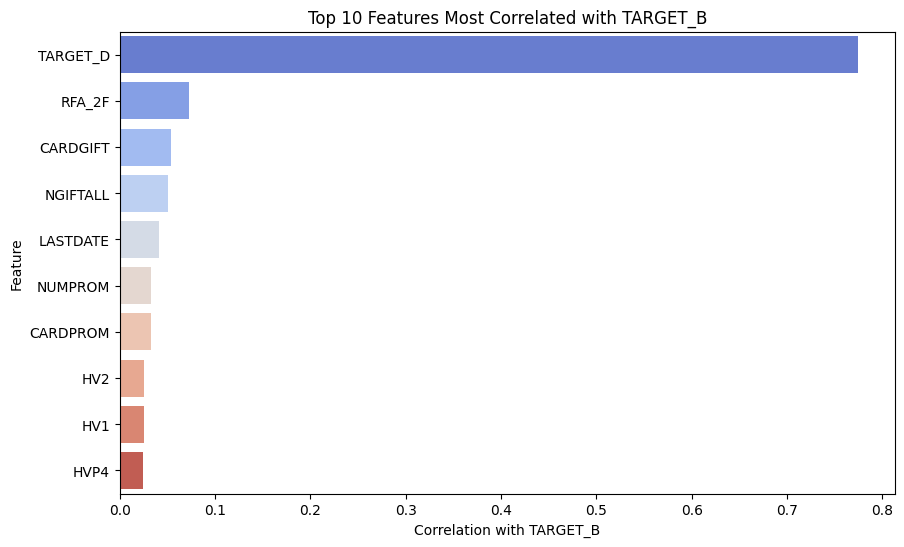

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features_with_target.values, y=top_features_with_target.index, palette="coolwarm")
plt.title("Top 10 Features Most Correlated with TARGET_B")
plt.xlabel("Correlation with TARGET_B")
plt.ylabel("Feature")
plt.show()

In [22]:
drop_cols = [
    'TARGET_D'
]
drop_cols = [c for c in drop_cols if c in cup98.columns]

cup98 = cup98.drop(columns=drop_cols)


### One-Hot Encoding Categories

In [23]:
if "TARGET_B" not in cup98.columns:
    raise ValueError("TARGET_B not found in CUP98 dataset.")

y = cup98["TARGET_B"].astype(int)

labels_df = pd.DataFrame(y)
labels_df.to_csv(model_data_path + "cup98_labels.csv", index=False, header=["TARGET_B"])

X_base = cup98.drop(columns=["TARGET_B"])



In [24]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

# Identify categorical & numeric columns
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns
num_cols = X_base.select_dtypes(exclude=["object", "category"]).columns

print("Fitting OneHotEncoder...")
ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    drop="first"
)

# Fit + transform categorical data
X_cat_sparse = ohe.fit_transform(X_base[cat_cols])

# Numeric features -> convert to sparse matrix
X_num_sparse = sparse.csr_matrix(X_base[num_cols].astype(float).values)

# Combine numeric + categorical
print("Combining sparse matrices...")
X_sparse = sparse.hstack([X_num_sparse, X_cat_sparse]).tocsr()

# Apply variance thresholding for feature reduction
print("Applying variance threshold...")
selector = VarianceThreshold(threshold=0.01)  # You can adjust the threshold as needed
X_sparse_reduced = selector.fit_transform(X_sparse)

# Save reduced features
print("Saving reduced features...")
sparse.save_npz(model_data_path+"cup98_features.npz", X_sparse_reduced)

print("DONE. Reduced sparse shape:", X_sparse_reduced.shape)


Fitting OneHotEncoder...
Combining sparse matrices...
Applying variance threshold...
Saving reduced features...
DONE. Reduced sparse shape: (95412, 974)


In [25]:
import shutil
shutil.rmtree(cleaned_data_path)